In this notebook, we would like to test the differences among greedy, unique greedy assignment and hungarian algorithm with cost function called cosine similairty which is one of the quality metric of real data and synthetic data  

# 1. Data loading and preparation

In [2]:
import warnings, numpy as np, pandas as pd
warnings.filterwarnings('ignore')

data = pd.read_excel('Sample.xlsx')

# droping diagnosis column which is not the main focus here

data.drop(['diagnosis'], axis = 1, inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   radius_mean   10 non-null     float64
 1   radius_se     10 non-null     float64
 2   radius_worst  10 non-null     float64
dtypes: float64(3)
memory usage: 372.0 bytes


In [3]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.0/197.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.3/198.3 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 5.9 MB/s eta 0:00:00


In [4]:
import sdv
from sdv.metadata import SingleTableMetadata
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)
print(f"Data shape: {data.shape}")
print(f"Columns: {list(data.columns)}")

Data shape: (10, 3)
Columns: ['radius_mean', 'radius_se', 'radius_worst']


In [5]:
from sdv.single_table import GaussianCopulaSynthesizer
model = GaussianCopulaSynthesizer(metadata=metadata)
model.fit(data)

In [6]:
synthetic_data_gaussian_copula = model.sample(10)

In [7]:
synthetic_data_gaussian_copula

,radius_mean,radius_se,radius_worst
0,20.26,0.4991,25.38
1,14.85,0.6578,16.07
2,15.05,0.4336,23.77
3,12.15,0.5404,21.79
4,17.92,0.7151,25.36
5,15.57,0.5245,14.99
6,16.27,0.6645,20.72
7,16.46,0.3369,25.38
8,20.57,0.9748,25.38
9,15.09,0.3762,14.92


In [8]:
data

,radius_mean,radius_se,radius_worst
0,17.99,1.0950,25.38
1,20.57,0.5435,24.99
2,19.69,0.7456,23.57
3,11.42,0.4956,14.91
4,20.29,0.7572,22.54
5,12.45,0.3345,15.47
6,18.25,0.4467,22.88
7,13.71,0.5835,17.06
8,13.00,0.3063,15.49
9,12.46,0.2976,15.09


Lets compute cosine similarity 10*10 matrix

In [9]:
from numpy.linalg import norm

real_data = data
synthetic_data = synthetic_data_gaussian_copula

# function to create similarity matrix

def normalize_rows(X):
  return X/(norm(X, axis=1, keepdims=True)+1e-12)

R = normalize_rows(real_data.to_numpy(float))
S = normalize_rows(synthetic_data.to_numpy(float))

cosine_matrix = R @ S.T

In [10]:
# print in readable format

cosine_df = pd.DataFrame(cosine_matrix, index=[f"R{i+1}" for i in range(10)], columns=[f"S{j+1}" for j in range(10)])
print(cosine_df)

           S1        S2        S3        S4        S5        S6        S7  \
R1   0.998177  0.991643  0.998444  0.994090  0.999925  0.982383  0.998749   
R2   0.999886  0.998273  0.992292  0.983833  0.997280  0.993290  0.999700   
R3   0.999713  0.998734  0.991330  0.982518  0.996739  0.994131  0.999542   
R4   0.999738  0.995736  0.995968  0.989506  0.999255  0.988663  0.999927   
R5   0.998201  0.999902  0.985802  0.974968  0.993077  0.997449  0.997741   
R6   0.999991  0.997582  0.993599  0.985748  0.998030  0.991957  0.999893   
R7   1.000000  0.997253  0.994082  0.986461  0.998281  0.991385  0.999921   
R8   0.999931  0.997616  0.993617  0.985867  0.998086  0.991895  0.999935   
R9   0.999699  0.998750  0.991067  0.982071  0.996523  0.994332  0.999420   
R10  0.999863  0.998338  0.992101  0.983547  0.997154  0.993453  0.999649   

           S8        S9       S10  
R1   0.998860  0.997910  0.984684  
R2   0.993570  0.999886  0.994765  
R3   0.992653  0.999874  0.995461  
R4   0.9

# 2. Greedy assignment

In [11]:
# Cosine similarity & association

def associate_real_with_synthetic(real_data: pd.DataFrame,synthetic_data: pd.DataFrame):

    num_cols = ["radius_mean", "radius_se", "radius_worst"]

    R = real_data[num_cols].to_numpy(dtype=float)
    S = synthetic_data[num_cols].to_numpy(dtype=float)

    # Normalize rows
    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    # Cosine similarity matrix (N_real x N_synth)

    cos_sim = R_norm @ S_norm.T

    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim   = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

# Call with DataFrames, not R, S

best_indices, best_sims, cos_matrix = associate_real_with_synthetic(real_data, synthetic_data)

print("Real → Synthetic associations (using cosine similarity):\n")
for i in range(len(real_data)):
    r_name = f"R{i+1}"
    s_name = f"S{best_indices[i] + 1}"
    sim_val = best_sims[i]
    print(f"{r_name}  →  {s_name}   cosine similarity = {sim_val:.4f}")

Real → Synthetic associations (using cosine similarity):

R1  →  S5   cosine similarity = 0.9999
R2  →  S1   cosine similarity = 0.9999
R3  →  S9   cosine similarity = 0.9999
R4  →  S7   cosine similarity = 0.9999
R5  →  S2   cosine similarity = 0.9999
R6  →  S1   cosine similarity = 1.0000
R7  →  S1   cosine similarity = 1.0000
R8  →  S9   cosine similarity = 1.0000
R9  →  S9   cosine similarity = 0.9997
R10  →  S1   cosine similarity = 0.9999


If we observe the above result,

*   S1 is used by R2, R6, R7, R10 → 4 times
*   S9 is used by R3, R8, R9 → 3 times

Greedy rule:

“For each real, pick the synthetic with the highest cosine similarity.”  the main disadvanatage with this algorithm is


*   *It ignores competition for the same synthetic sample*
*   *It’s inconsistent with the idea of “sample-level” similarity*

# 3. Unique Greedy assignment

What this “unique greedy” algorithm does

For each real Ri, it sorts its candidate synthetics by cosine similarity.

It sorts real samples by their best possible similarity (strongest first).

In [14]:
#  For each real sample, assign a unique synthetic sample:
#     - use cosine similarity
#     - if the best synthetic is already taken, use the next-best one.

#     Returns
#     -------
#     assigned_synth : np.ndarray
#         Index of the synthetic assigned to each real (shape: N_real, values in 0..M-1).
#     assigned_sim   : np.ndarray
#         Cosine similarity for that assignment (shape: N_real).
#     cos_sim        : np.ndarray
#         Full cosine similarity matrix (N_real x N_synth).

In [15]:
def associate_real_with_synthetic_unique(real_df: pd.DataFrame,synth_df: pd.DataFrame):

    num_cols = ["radius_mean", "radius_se", "radius_worst"]

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    # Normalize rows
    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    # Cosine similarity matrix (N_real x N_synth)
    cos_sim = R_norm @ S_norm.T

    n_real, n_synth = cos_sim.shape

    # For each real sample, get synthetic indices sorted by similarity (descending)

    sorted_synth_indices = np.argsort(-cos_sim, axis=1)  # negative for descending

    # Order reals by how strong their best match is (strongest first)
    best_per_real = cos_sim.max(axis=1)
    real_order = np.argsort(-best_per_real)  # indices of reals, strongest first

    assigned_synth = -np.ones(n_real, dtype=int)   # -1 = not yet assigned
    assigned_sim = np.zeros(n_real, dtype=float)
    used_synth = set()

    # Greedy assignment: strongest reals choose first
    for i in real_order:
        for j in sorted_synth_indices[i]:
            if j not in used_synth:
                assigned_synth[i] = j
                assigned_sim[i] = cos_sim[i, j]
                used_synth.add(j)
                break

    return assigned_synth, assigned_sim, cos_sim

In [17]:
best_indices, best_sims, cos_matrix = associate_real_with_synthetic_unique(real_data, synthetic_data)

print("Real → Synthetic associations (unique, using cosine similarity):\n")
for i in range(len(real_data)):
    r_name = f"R{i+1}"
    if best_indices[i] == -1:
        print(f"{r_name}  →  (no available synthetic left)")
    else:
        s_name = f"S{best_indices[i] + 1}"
        sim_val = best_sims[i]
        print(f"{r_name}  →  {s_name}   cosine similarity = {sim_val:.4f}")

Real → Synthetic associations (unique, using cosine similarity):

R1  →  S8   cosine similarity = 0.9989
R2  →  S10   cosine similarity = 0.9948
R3  →  S6   cosine similarity = 0.9941
R4  →  S5   cosine similarity = 0.9993
R5  →  S2   cosine similarity = 0.9999
R6  →  S9   cosine similarity = 0.9999
R7  →  S1   cosine similarity = 1.0000
R8  →  S7   cosine similarity = 0.9999
R9  →  S4   cosine similarity = 0.9821
R10  →  S3   cosine similarity = 0.9921



In that order, each real picks the best synthetic that’s still free. So R7 (with a super-strong match S1, 1.0000) might grab S1 first, then later R2—who also likes S1—has to settle for S10 (0.9948), and so on.

This is already much better than the naive greedy, but…

The remaining problem: it’s not guaranteed globally optimal

“Unique greedy” makes locally good decisions, one real at a time, but it does not explore all combinations. There might exist another assignment like:

R2 ↔ S6

R3 ↔ S10

where the sum / average of similarities over all 10 pairs is even higher than in your current result. Greedy won’t see that, because once it has assigned S6 and S10 earlier in the process, it never revisits and reshuffles them.

# 4. Hungarian algorithm

                num_cols=None):
    """
    Perform optimal 1-to-1 matching between real and synthetic samples
    using the Hungarian algorithm on (1 - cosine_similarity) as cost.

    Returns
    -------
    row_ind : np.ndarray
        Indices of real samples in the matching (0-based).
    col_ind : np.ndarray
        Indices of synthetic samples matched to each real (0-based).
    selected_similarities : np.ndarray
        Cosine similarity values for each matched pair.
    avg_similarity : float
        Average cosine similarity over the matched pairs.
    cos_sim : np.ndarray
        Full cosine similarity matrix (N_real x N_synth).
    """

In [31]:
import re
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment


# Row normalization for cosine similarity

def normalize_rows(X: np.ndarray) -> np.ndarray:
    """
    Normalize each row vector in X to unit L2 norm.
    """
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms


# Build cosine similarity matrix

def cosine_similarity_matrix(real_df: pd.DataFrame,
                             synth_df: pd.DataFrame,
                             num_cols=None) -> np.ndarray:
    """
    Compute cosine similarity matrix between real and synthetic samples.
    Returns an (N_real x N_synth) matrix.
    """
    if num_cols is None:

        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    return cos_sim


# Hungarian-based optimal matching

def hungarian_match(real_df: pd.DataFrame,
                    synth_df: pd.DataFrame,
                    num_cols=None):

    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    # We want to maximize similarity → minimize cost = 1 - similarity

    if n_real <= n_synth:

        cost_matrix = 1.0 - cos_sim
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]

    else:
        cost_matrix = 1.0 - cos_sim.T
        col_ind, row_ind = linear_sum_assignment(cost_matrix)
        selected_similarities = cos_sim[row_ind, col_ind]

    avg_similarity = float(selected_similarities.mean())

    return row_ind, col_ind, selected_similarities, avg_similarity, cos_sim


real_df = real_data
synth_df = synthetic_data

num_cols = ["radius_mean", "radius_se", "radius_worst"]

row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(
    real_df, synth_df, num_cols=num_cols
)

In [32]:
print("Optimal Real → Synthetic assignments (Hungarian, using cosine similarity):\n")
for r_idx, s_idx, sim in zip(row_ind, col_ind, sims):
    r_name = f"R{r_idx + 1}"
    s_name = f"S{s_idx + 1}"
    print(f"{r_name}  →  {s_name}   cosine similarity = {sim:.4f}")

print(f"\nAverage cosine similarity over matched pairs: {avg_sim:.4f}")

Optimal Real → Synthetic assignments (Hungarian, using cosine similarity):

R1  →  S4   cosine similarity = 0.9941
R2  →  S9   cosine similarity = 0.9999
R3  →  S2   cosine similarity = 0.9987
R4  →  S3   cosine similarity = 0.9960
R5  →  S6   cosine similarity = 0.9974
R6  →  S7   cosine similarity = 0.9999
R7  →  S8   cosine similarity = 0.9952
R8  →  S5   cosine similarity = 0.9981
R9  →  S10   cosine similarity = 0.9957
R10  →  S1   cosine similarity = 0.9999

Average cosine similarity over matched pairs: 0.9975


## 4.1. Scenario 1

This is the condition where we consider the scenario where |R| = |S|. It is possible that the number of synthetic samples is significantly larger than the real ones, i.e., |R| > |S|.

Lets imagine

Number of real samples = N
Number of synthetic samples = 5N

In such a case, we will:

- Use the Hungarian algorithm to select the best N synthetic samples (Option 1).
- For the remaining 4N synthetic samples, compute their closeness to the real data (Option 2).
- Optionally, filter out synthetic samples that are "too close" to any real sample (for privacy).

In [36]:
# creating synthetic data with 50 samples

synthetic_data_gaussian_copula = model.sample(50)
synthetic_data_gaussian_copula.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   radius_mean   50 non-null     float64
 1   radius_se     50 non-null     float64
 2   radius_worst  50 non-null     float64
dtypes: float64(3)
memory usage: 1.3 KB


In [37]:
# Hungarian assignment for |S| >= |R|

def hungarian_match_subset(real_df: pd.DataFrame,
                           synth_df: pd.DataFrame,
                           num_cols,
                           privacy_threshold: float = 0.95):
    """
    Case: |S| >= |R| (e.g., synthetic is 5x real).

    1. Use Hungarian algorithm to pick the best |R| synthetic samples.
    2. For remaining synthetic samples, compute their max similarity to real.
    3. Optionally mark those above privacy_threshold as too-close.
    """

    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_synth < n_real:
        raise ValueError("This function assumes |S| >= |R|.")

    # 1. Hungarian on full cost matrix (N_real x N_synth)

    cost_matrix = 1.0 - cos_sim
    row_ind, col_ind = linear_sum_assignment(cost_matrix)

    # These are the chosen best |R| synthetic samples

    selected_similarities = cos_sim[row_ind, col_ind]
    avg_similarity = float(selected_similarities.mean())

    # 2. Remaining synthetic samples

    all_synth_indices = set(range(n_synth))
    matched_synth_indices = set(col_ind.tolist())
    remaining_synth_indices = sorted(list(all_synth_indices - matched_synth_indices))

    # For remaining synthetics, compute max similarity to any real

    max_sim_remaining = {}
    for j in remaining_synth_indices:
        # cosine similarities of synthetic j to all real samples = cos_sim[:, j]
        max_sim = float(cos_sim[:, j].max())
        max_sim_remaining[j] = max_sim

    # 3. Optionally, identify too-close synthetic samples for privacy
    too_close = {j: s for j, s in max_sim_remaining.items()
                 if s >= privacy_threshold}

    return {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "selected_similarities": selected_similarities,
        "avg_similarity": avg_similarity,
        "cos_sim": cos_sim,
        "remaining_synth_indices": remaining_synth_indices,
        "max_sim_remaining": max_sim_remaining,
        "too_close": too_close
    }




real_df = real_data
synth_df = synthetic_data_gaussian_copula

num_cols = ["radius_mean", "radius_se", "radius_worst"]

result = hungarian_match_subset(real_df, synth_df, num_cols,
                                privacy_threshold=0.95)

row_ind = result["row_ind"]
col_ind = result["col_ind"]
sims = result["selected_similarities"]
avg_sim = result["avg_similarity"]

print("Optimal Real → Synthetic assignments (Hungarian, |S| > |R|):\n")
for r_idx, s_idx, sim in zip(row_ind, col_ind, sims):
    r_name = f"R{r_idx + 1}"
    s_name = f"S{s_idx + 1}"
    print(f"{r_name}  →  {s_name}   cosine similarity = {sim:.4f}")

print(f"\nAverage cosine similarity over matched pairs: {avg_sim:.4f}")

print("\nPrivacy check on remaining synthetic samples:")
print(f"Total synthetic samples: {synth_df.shape[0]}")
print(f"Matched synthetic samples: {len(col_ind)}")
print(f"Remaining synthetic samples: {len(result['remaining_synth_indices'])}")

print("\nNumber of remaining synthetic samples too close to real "
      f"(cosine >= 0.95): {len(result['too_close'])}")

for j, sim in result["too_close"].items():
    print(f"S{j+1} is too close to some real sample (max cosine = {sim:.4f})")


Optimal Real → Synthetic assignments (Hungarian, |S| > |R|):

R1  →  S18   cosine similarity = 0.9999
R2  →  S46   cosine similarity = 1.0000
R3  →  S31   cosine similarity = 1.0000
R4  →  S28   cosine similarity = 1.0000
R5  →  S3   cosine similarity = 0.9999
R6  →  S10   cosine similarity = 1.0000
R7  →  S2   cosine similarity = 1.0000
R8  →  S1   cosine similarity = 1.0000
R9  →  S49   cosine similarity = 1.0000
R10  →  S6   cosine similarity = 1.0000

Average cosine similarity over matched pairs: 1.0000

Privacy check on remaining synthetic samples:
Total synthetic samples: 50
Matched synthetic samples: 10
Remaining synthetic samples: 40

Number of remaining synthetic samples too close to real (cosine >= 0.95): 40
S4 is too close to some real sample (max cosine = 0.9911)
S5 is too close to some real sample (max cosine = 1.0000)
S7 is too close to some real sample (max cosine = 0.9999)
S8 is too close to some real sample (max cosine = 0.9976)
S9 is too close to some real sample (max

## 4.2. Scenario 2

what if we generate 500 synthetic samples (500*S) for 10 real samples |S| >> |R|

 """
    Case: |S| >> |R|

    1. Cluster synthetic samples into K clusters (K = |R| by default).
    2. Use cluster centroids as representative synthetic points.
    3. Match each real sample to the nearest centroid using cosine similarity.

    Returns
    -------
    centroid_assignments : np.ndarray
        For each real sample i, the index (0..K-1) of the centroid it is closest to.
    centroid_similarities : np.ndarray
        Cosine similarity between each real sample and its assigned centroid.
    centroids : np.ndarray
        The centroid vectors in original feature space (shape: K x d).
    cos_sim_matrix : np.ndarray
        Cosine similarity matrix between real samples and centroids (N_real x K).
    kmeans_labels : np.ndarray
        Cluster label for each synthetic sample (length |S|).
    """

In [38]:
# lets create synthetic data with 500 samples

synthetic_data_gaussian_copula = model.sample(500)
synthetic_data_gaussian_copula.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   radius_mean   500 non-null    float64
 1   radius_se     500 non-null    float64
 2   radius_worst  500 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB


In [58]:
# Cluster synthetic data and match real to centroids

from sklearn.cluster import KMeans

def cluster_synthetic_and_match(real_df: pd.DataFrame,
                                synth_df: pd.DataFrame,
                                num_cols,
                                n_clusters: int = None,
                                random_state: int = 0):

    # Extract numeric data
    R = real_df[num_cols].to_numpy(dtype=float)
    S = synth_df[num_cols].to_numpy(dtype=float)

    n_real = R.shape[0]


    if n_clusters is None:
        n_clusters = n_real

    # Normalize synthetic data for clustering (cosine ~ Euclidean on unit sphere)
    S_norm = normalize_rows(S)

    # ---------- KMeans clustering on synthetic samples ----------
    kmeans = KMeans(n_clusters=n_clusters,
                    random_state=random_state,
                    n_init=10)
    kmeans.fit(S_norm)

    # Centroids are in normalized space; we can treat them as direction vectors
    centroids = kmeans.cluster_centers_        # shape: (K, d)
    centroids_norm = normalize_rows(centroids) # just to be safe

    # Normalize real data for cosine similarity
    R_norm = normalize_rows(R)

    # ---------- Cosine similarity: real vs centroids ----------
    # cos_sim[i, k] = cosine similarity between real i and centroid k
    cos_sim_matrix = R_norm @ centroids_norm.T   # shape: (N_real, K)

    # For each real sample, find the closest centroid (max cosine similarity)
    centroid_assignments = np.argmax(cos_sim_matrix, axis=1)
    centroid_similarities = cos_sim_matrix[np.arange(n_real), centroid_assignments]

    return (centroid_assignments,
            centroid_similarities,
            centroids,
            cos_sim_matrix,
            kmeans.labels_)

In [60]:

real_df = real_data
synth_df = synthetic_data_gaussian_copula

num_cols = ["radius_mean", "radius_se", "radius_worst"]

(centroid_assignments,
 centroid_sims,
 centroids,
 cos_sim_centroids,
 synth_cluster_labels) = cluster_synthetic_and_match(
    real_df,
    synth_df,
    num_cols=num_cols,
    n_clusters=len(real_df),  # usually use |R|
    random_state=42
)

print("Real → Centroid assignments (|S| >> |R|, clustered):\n")
for i, (c_idx, sim) in enumerate(zip(centroid_assignments, centroid_sims)):
    r_name = f"R{i+1}"
    print(f"{r_name}  →  Centroid {c_idx}   cosine similarity = {sim:.4f}")

avg_centroid_sim = float(centroid_sims.mean())
print(f"\nAverage cosine similarity (real vs assigned centroid): {avg_centroid_sim:.4f}")


# synthetic samples in each cluster

print('===================================================')

cluster_counts = np.bincount(synth_cluster_labels)
print("\nNumber of synthetic samples per cluster (approx per real):")
for k, count in enumerate(cluster_counts):
    print(f"Cluster {k}: {count} synthetic samples")

Real → Centroid assignments (|S| >> |R|, clustered):

R1  →  Centroid 3   cosine similarity = 0.9998
R2  →  Centroid 1   cosine similarity = 1.0000
R3  →  Centroid 1   cosine similarity = 0.9999
R4  →  Centroid 5   cosine similarity = 1.0000
R5  →  Centroid 6   cosine similarity = 0.9999
R6  →  Centroid 1   cosine similarity = 1.0000
R7  →  Centroid 1   cosine similarity = 0.9999
R8  →  Centroid 1   cosine similarity = 1.0000
R9  →  Centroid 1   cosine similarity = 0.9998
R10  →  Centroid 1   cosine similarity = 0.9999

Average cosine similarity (real vs assigned centroid): 0.9999

Number of synthetic samples per cluster (approx per real):
Cluster 0: 50 synthetic samples
Cluster 1: 113 synthetic samples
Cluster 2: 20 synthetic samples
Cluster 3: 63 synthetic samples
Cluster 4: 41 synthetic samples
Cluster 5: 108 synthetic samples
Cluster 6: 52 synthetic samples
Cluster 7: 11 synthetic samples
Cluster 8: 9 synthetic samples
Cluster 9: 33 synthetic samples


# 5. Graphical visulization

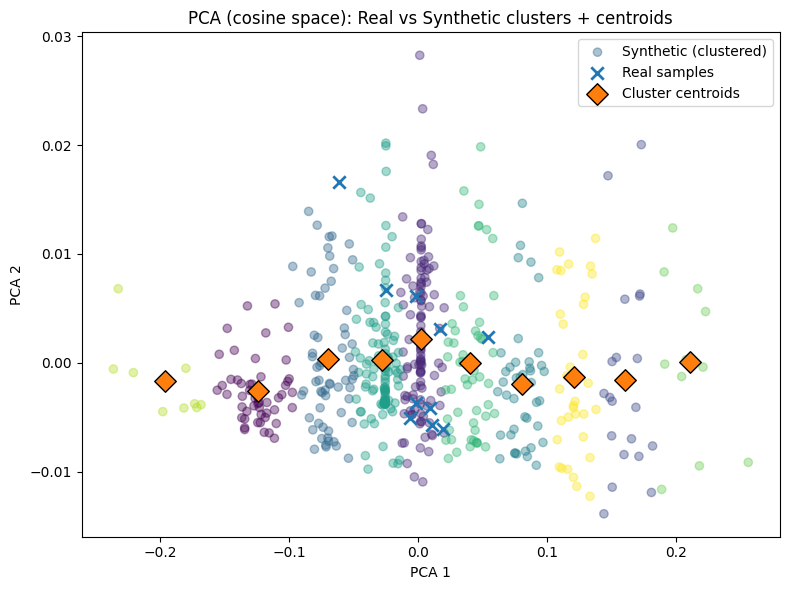

In [64]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_real = real_df[num_cols].to_numpy(dtype=float)
X_synth = synthetic_data_gaussian_copula[num_cols].to_numpy(dtype=float)

X_real_norm = normalize_rows(X_real)
X_synth_norm = normalize_rows(X_synth)
centroids_norm = normalize_rows(centroids)

n_real = X_real_norm.shape[0]
n_synth = X_synth_norm.shape[0]
n_centroids = centroids_norm.shape[0]


# stack and fit PCA on the unified normalized space

X_all_norm = np.vstack([X_real_norm, X_synth_norm, centroids_norm])
pca = PCA(n_components=2)
X_all_2d = pca.fit_transform(X_all_norm)

# spilt back into real, synthetic and centroids

X_real_2d = X_all_2d[:n_real]
X_synth_2d = X_all_2d[n_real:n_real + n_synth]
X_centroids_2d = X_all_2d[n_real + n_synth:]


plt.figure(figsize=(8, 6))

# synthetic_Samples

plt.scatter(
    X_synth_2d[:, 0],
    X_synth_2d[:, 1],
    c=synth_cluster_labels,
    alpha=0.4,
    marker='o',
    label="Synthetic (clustered)"
)

# Real samples
plt.scatter(
    X_real_2d[:, 0],
    X_real_2d[:, 1],
    marker='x',
    s=80,
    linewidths=2,
    label="Real samples"
)

# Cluster centroids
plt.scatter(
    X_centroids_2d[:, 0],
    X_centroids_2d[:, 1],
    marker='D',
    s=120,
    edgecolors='black',
    label="Cluster centroids"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA (cosine space): Real vs Synthetic clusters + centroids")
plt.legend()
plt.tight_layout()
plt.show()


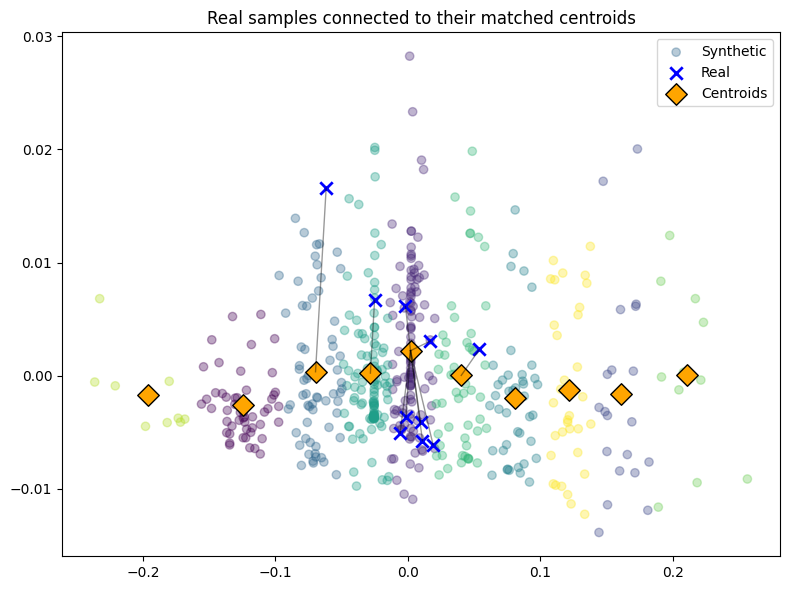

In [66]:
# Lines connecting real samples → their assigned centroid

plt.figure(figsize=(8,6))

# Synthetic points
plt.scatter(
    X_synth_2d[:,0], X_synth_2d[:,1],
    c=synth_cluster_labels, alpha=0.35, label="Synthetic"
)

# Real points
plt.scatter(
    X_real_2d[:,0], X_real_2d[:,1],
    marker='x', s=80, linewidths=2, color='blue',
    label="Real"
)

# Centroids
plt.scatter(
    X_centroids_2d[:,0], X_centroids_2d[:,1],
    marker='D', s=120, edgecolors='black', color='orange',
    label="Centroids"
)

# Draw a line between each real sample and its assigned centroid
for i, c_idx in enumerate(centroid_assignments):
    x1, y1 = X_real_2d[i]
    x2, y2 = X_centroids_2d[c_idx]
    plt.plot([x1, x2], [y1, y2], color='black', alpha=0.4, linewidth=1)

plt.title("Real samples connected to their matched centroids")
plt.legend()
plt.tight_layout()
plt.show()

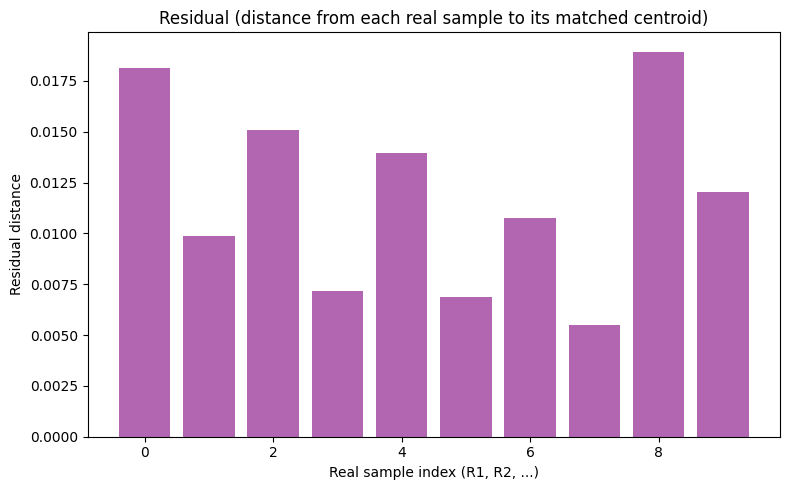

In [67]:
# Residual Visualization: distance from each real → centroid

# Compute residuals in original normalized space
residuals = np.linalg.norm(X_real_norm - centroids_norm[centroid_assignments], axis=1)

# Bar chart of residuals
plt.figure(figsize=(8,5))
plt.bar(range(len(residuals)), residuals, color='purple', alpha=0.6)
plt.xlabel("Real sample index (R1, R2, ...)")
plt.ylabel("Residual distance")
plt.title("Residual (distance from each real sample to its matched centroid)")
plt.tight_layout()
plt.show()

In [68]:
for i, r in enumerate(residuals):
    print(f"R{i+1} → centroid {centroid_assignments[i]} residual = {r:.4f}")

R1 → centroid 3 residual = 0.0182
R2 → centroid 1 residual = 0.0099
R3 → centroid 1 residual = 0.0151
R4 → centroid 5 residual = 0.0072
R5 → centroid 6 residual = 0.0139
R6 → centroid 1 residual = 0.0069
R7 → centroid 1 residual = 0.0108
R8 → centroid 1 residual = 0.0055
R9 → centroid 1 residual = 0.0189
R10 → centroid 1 residual = 0.0121


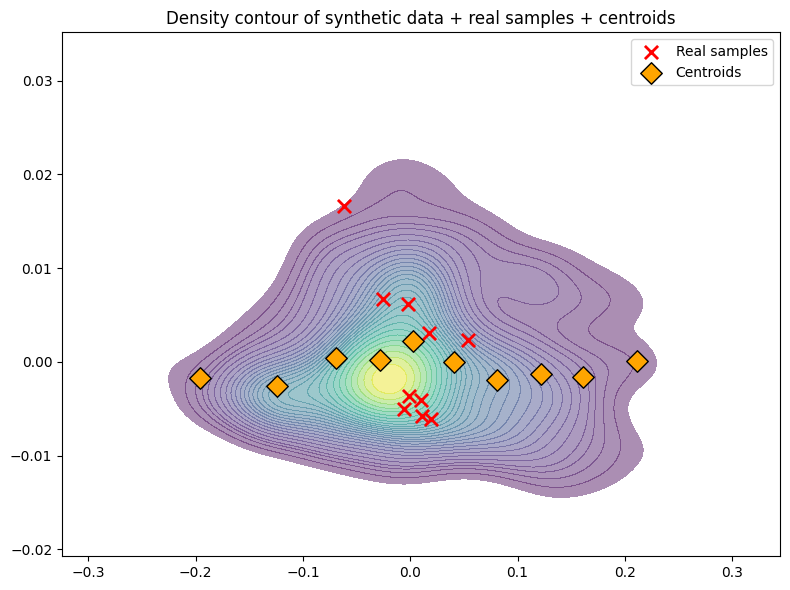

In [69]:
import seaborn as sns

plt.figure(figsize=(8,6))

# Density of synthetic points
sns.kdeplot(
    x=X_synth_2d[:,0],
    y=X_synth_2d[:,1],
    fill=True, cmap="viridis", alpha=0.45, thresh=0.05,
    levels=30
)

# Overlay real points
plt.scatter(
    X_real_2d[:,0], X_real_2d[:,1],
    marker='x', s=90, linewidth=2, color='red',
    label="Real samples"
)

# Overlay centroids
plt.scatter(
    X_centroids_2d[:,0], X_centroids_2d[:,1],
    marker='D', s=120, edgecolors='black', color='orange',
    label="Centroids"
)

plt.title("Density contour of synthetic data + real samples + centroids")
plt.legend()
plt.tight_layout()
plt.show()